# 06 SVM Tuning Experiments

SVM-focused TF-IDF hyperparameter tuning and class imbalance experiments for the final 1,000-row MBG labeled sample. Macro F1 is prioritized because the dataset is imbalanced, especially for the `negatif` class. These are tuning experiments, not final thesis conclusions.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "mbg_labeled_sample_1000.csv"
REPORTS_DIR = PROJECT_ROOT / "outputs" / "reports"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

## Load Final Labeled Dataset

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
df.head()

Rows: 1,000
Columns: ['batch_id', 'sample_id', 'clean_text', 'label', 'label_before_adjudication', 'label_after_adjudication', 'adjudication_applied', 'human_label', 'human_notes', 'adjudication_review_reason']


,batch_id,sample_id,clean_text,label,label_before_adjudication,label_after_adjudication,adjudication_applied,human_label,human_notes,adjudication_review_reason
0,1,label_sample_0001,belum selesai lomba di mbg sekarang udah di li...,netral,netral,netral,True,netral,teks ambigu tanpa polaritas jelas,catatan menunjukkan konteks ambigu/informatif
1,1,label_sample_0002,good job polri rekrut gizi spesialis buat mbg ...,positif,positif,positif,False,NaN,NaN,NaN
2,1,label_sample_0003,dapoer ibu boyolali terus salurkan mbg untuk p...,positif,netral,positif,True,positif,seperti support mbg,catatan menunjukkan konteks ambigu/informatif
3,1,label_sample_0004,duitnya buat mbg ga bisa bayar artist lokal,negatif,negatif,negatif,False,NaN,NaN,NaN
4,1,label_sample_0005,deket rumah udah ada simulasi makan bergizi gr...,netral,netral,netral,True,netral,informasi simulasi tanpa opini,catatan menunjukkan konteks ambigu/informatif


## Label Distribution

In [3]:
label_counts = df["label"].value_counts().rename("count")
label_distribution = label_counts.to_frame()
label_distribution["percentage"] = (label_distribution["count"] / len(df) * 100).round(2)
label_distribution

,count,percentage
label,,
netral,472,47.2
positif,412,41.2
negatif,116,11.6


## Run SVM Tuning Script Logic

In [4]:
from run_svm_tuning_experiments import run_svm_tuning_experiments

summary = run_svm_tuning_experiments()
summary["best_svm"]

Loaded dataset: C:\Users\hpdk1\Documents\Projects\mbg-sentiment-analysis\data\processed\mbg_labeled_sample_1000.csv
Total rows: 1000
Label distribution:
  negatif: 116 (11.60%)
  netral: 472 (47.20%)
  positif: 412 (41.20%)
Tuning Tuned LinearSVC...


Tuning Tuned SVC Linear Kernel...


Tuning Tuned SVC RBF Kernel...


All CV results saved to: C:\Users\hpdk1\Documents\Projects\mbg-sentiment-analysis\outputs\reports\15_svm_tuning_all_cv_results.csv
Test results saved to: C:\Users\hpdk1\Documents\Projects\mbg-sentiment-analysis\outputs\reports\15_svm_tuning_test_results.csv
Summary JSON saved to: C:\Users\hpdk1\Documents\Projects\mbg-sentiment-analysis\outputs\reports\15_svm_tuning_summary.json
Markdown report saved to: C:\Users\hpdk1\Documents\Projects\mbg-sentiment-analysis\outputs\reports\15_svm_tuning_report.md
Best SVM saved to: C:\Users\hpdk1\Documents\Projects\mbg-sentiment-analysis\outputs\models\best_svm_model.joblib
Best SVM metadata saved to: C:\Users\hpdk1\Documents\Projects\mbg-sentiment-analysis\outputs\models\best_svm_model_metadata.json
Best tuned SVM by test macro F1: Tuned LinearSVC (0.7278)


{'experiment': 'tuned_linearsvc',
 'experiment_display_name': 'Tuned LinearSVC',
 'selection_metric': 'test_f1_macro',
 'test_f1_macro': 0.7277609525922104,
 'test_metrics': {'accuracy': 0.795,
  'precision_macro': 0.7454772150502041,
  'recall_macro': 0.7159885397480976,
  'f1_macro': 0.7277609525922104,
  'f1_weighted': 0.7930102218661017},
 'best_params': {'classifier__C': 0.5,
  'classifier__class_weight': 'balanced',
  'tfidf__max_df': 0.9,
  'tfidf__min_df': 3,
  'tfidf__ngram_range': [1, 2],
  'tfidf__sublinear_tf': True},
 'artifact_path': 'C:\\Users\\hpdk1\\Documents\\Projects\\mbg-sentiment-analysis\\outputs\\models\\best_svm_model.joblib',
 'metadata_path': 'C:\\Users\\hpdk1\\Documents\\Projects\\mbg-sentiment-analysis\\outputs\\models\\best_svm_model_metadata.json'}

## Test Results

In [5]:
test_results = pd.read_csv(REPORTS_DIR / "15_svm_tuning_test_results.csv")
test_results

,experiment,experiment_display_name,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,tuned_linearsvc,Tuned LinearSVC,0.692395,0.795,0.745477,0.715989,0.727761,0.793010
1,tuned_svc_linear,Tuned SVC Linear Kernel,0.696580,0.795,0.747504,0.713763,0.724858,0.793770
2,tuned_svc_rbf,Tuned SVC RBF Kernel,0.691738,0.795,0.750557,0.713207,0.724738,0.793735


## Best Parameters

In [6]:
with open(REPORTS_DIR / "15_svm_tuning_summary.json", encoding="utf-8") as file_obj:
    saved_summary = json.load(file_obj)

best_params = pd.DataFrame(
    [
        {
            "experiment": key,
            "display_name": value["display_name"],
            "best_cv_macro_f1": value["best_cv_macro_f1"],
            "best_params": json.dumps(value["best_params"], ensure_ascii=False, sort_keys=True),
        }
        for key, value in saved_summary["experiments"].items()
    ]
)
best_params

,experiment,display_name,best_cv_macro_f1,best_params
0,tuned_linearsvc,Tuned LinearSVC,0.692395,"{""classifier__C"": 0.5, ""classifier__class_weig..."
1,tuned_svc_linear,Tuned SVC Linear Kernel,0.696580,"{""classifier__C"": 1, ""classifier__class_weight..."
2,tuned_svc_rbf,Tuned SVC RBF Kernel,0.691738,"{""classifier__C"": 5, ""classifier__class_weight..."


## Confusion Matrices

15_confusion_matrix_tuned_linearsvc.png


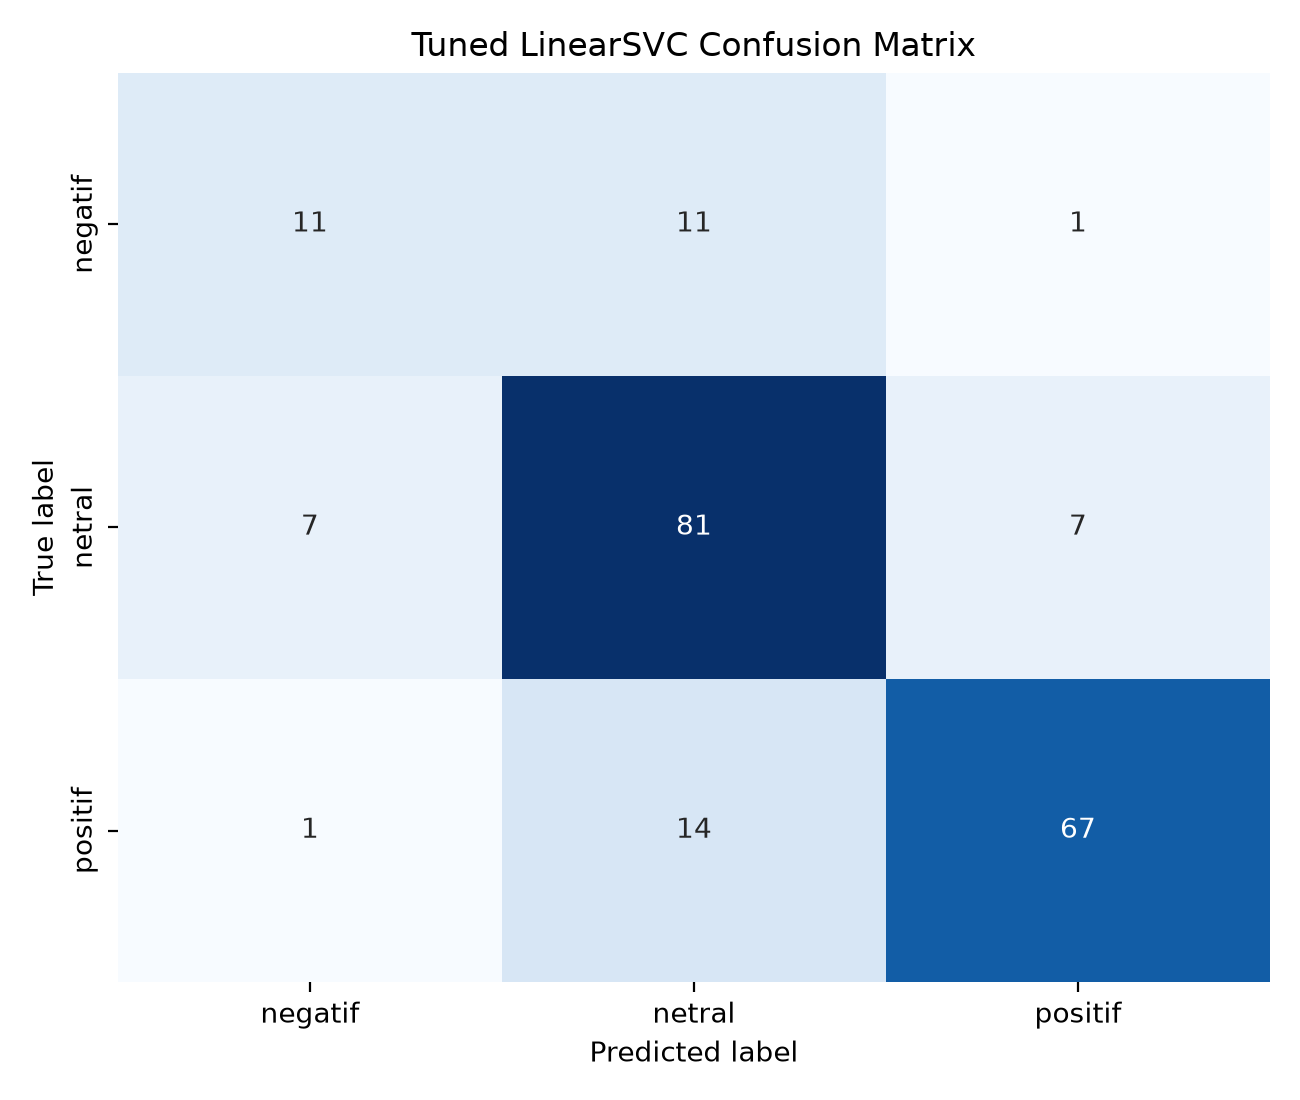

15_confusion_matrix_tuned_svc_linear.png


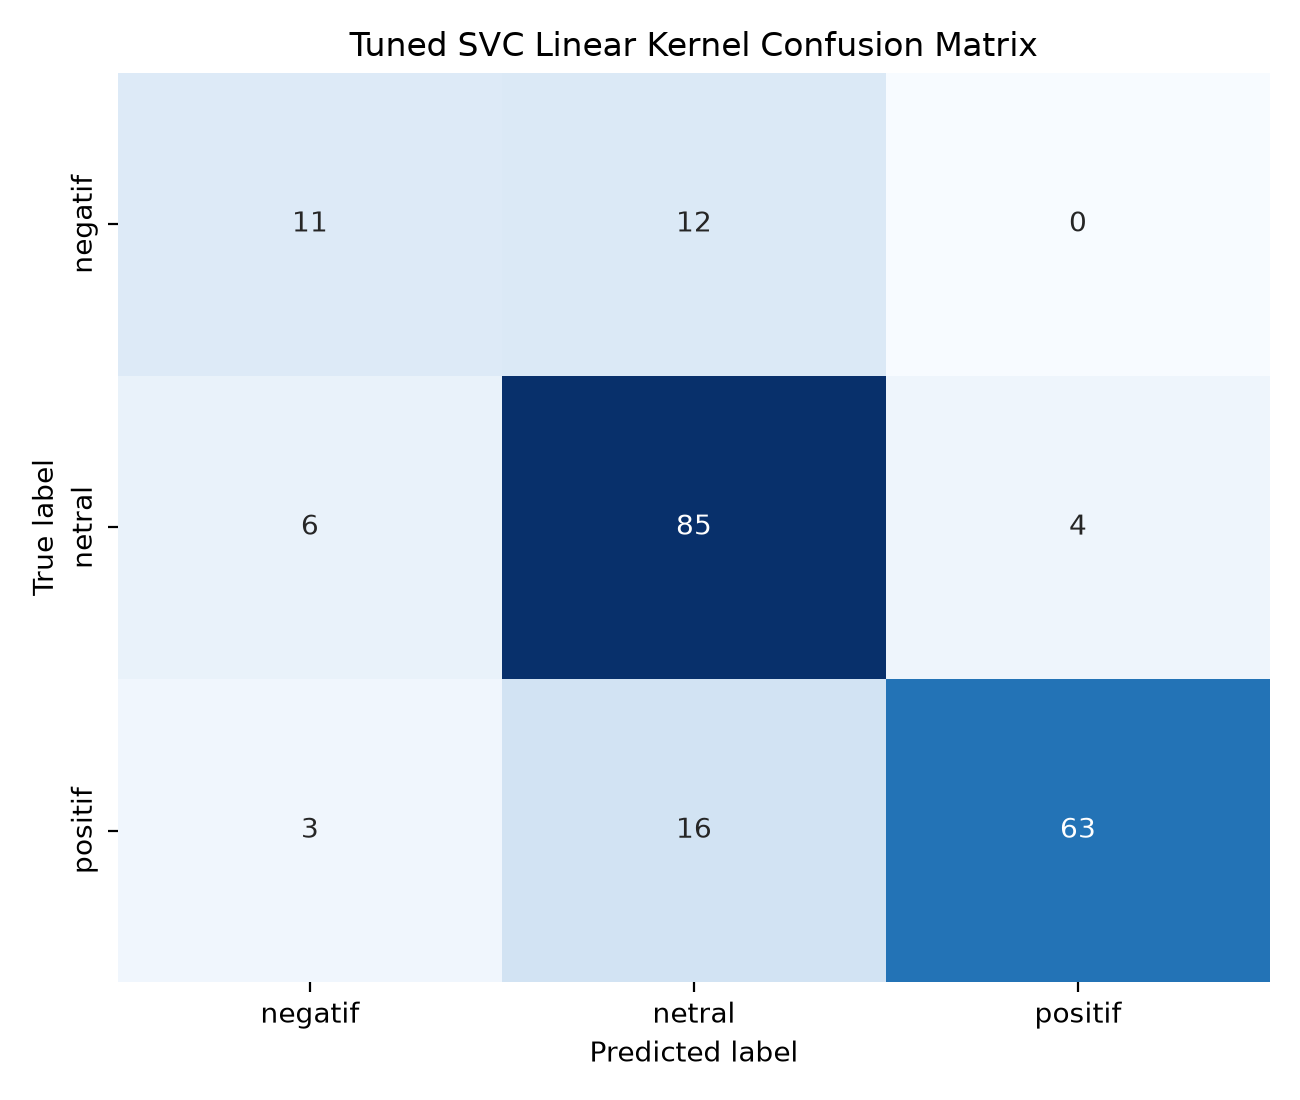

15_confusion_matrix_tuned_svc_rbf.png


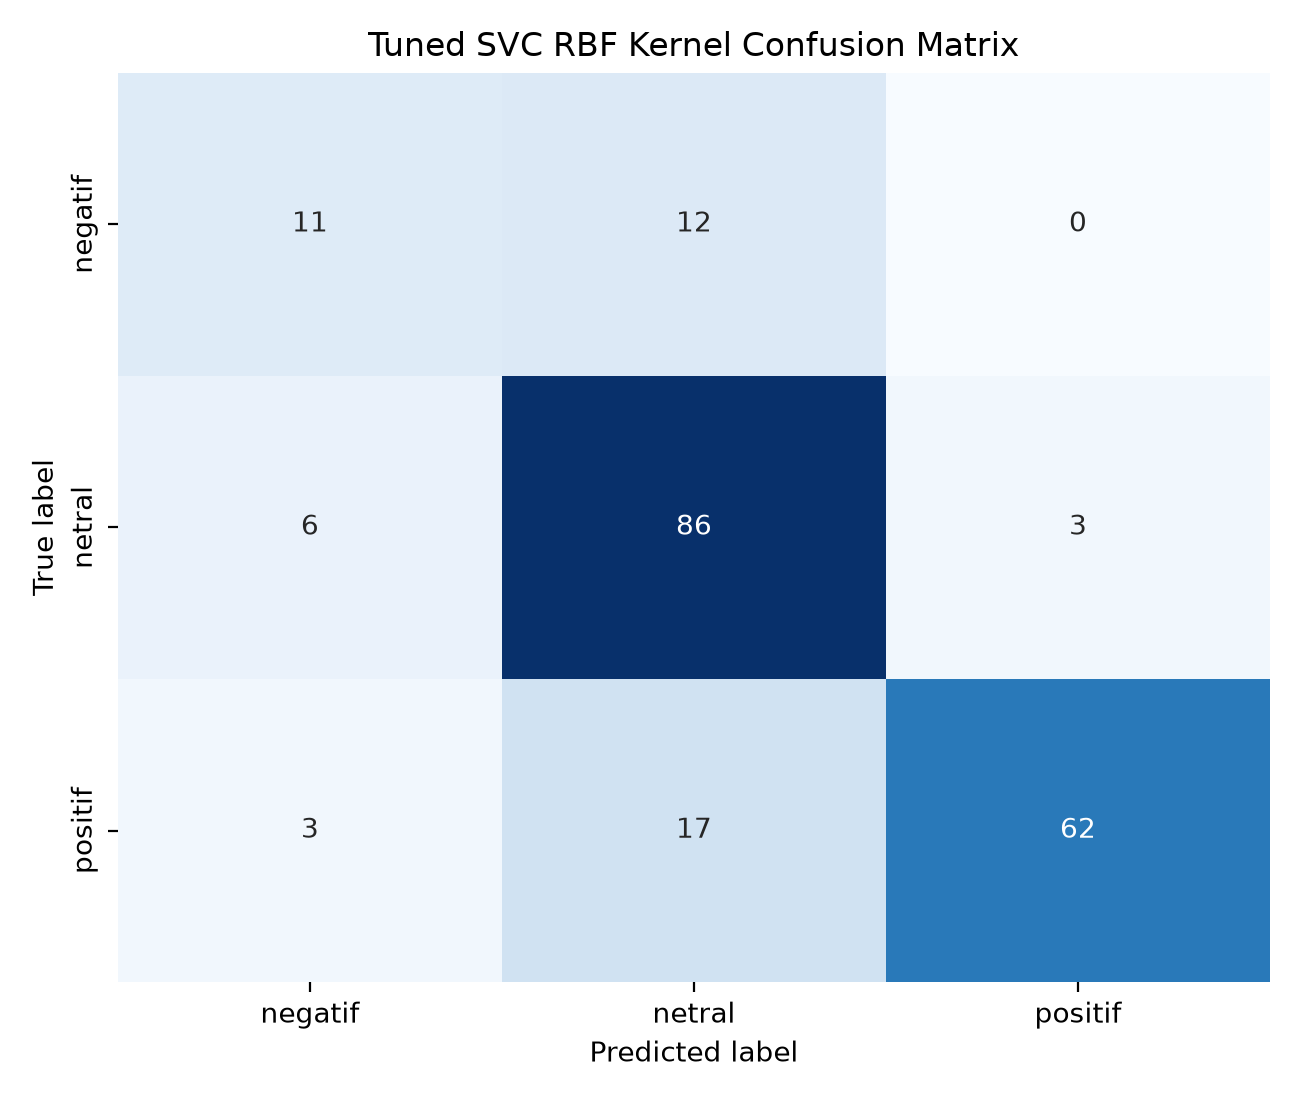

In [7]:
confusion_matrix_paths = [
    FIGURES_DIR / "15_confusion_matrix_tuned_linearsvc.png",
    FIGURES_DIR / "15_confusion_matrix_tuned_svc_linear.png",
    FIGURES_DIR / "15_confusion_matrix_tuned_svc_rbf.png",
]
for path in confusion_matrix_paths:
    print(path.name)
    display(Image(filename=str(path)))

## Best SVM by Macro F1

In [8]:
best_svm = saved_summary["best_svm"]
print(f"Best tuned SVM by test macro F1: {best_svm['experiment_display_name']} ({best_svm['experiment']})")
print(f"Test macro F1: {best_svm['test_f1_macro']:.4f}")
print(f"Model artifact: {best_svm['artifact_path']}")

comparison = saved_summary["comparison_to_logistic_regression_baseline"]
if comparison["baseline_available"]:
    print(f"Logistic Regression baseline macro F1: {comparison['logistic_regression_f1_macro']:.4f}")
    print(f"Tuned SVM underperforms Logistic Regression baseline: {comparison['tuned_svm_underperforms']}")

Best tuned SVM by test macro F1: Tuned LinearSVC (tuned_linearsvc)
Test macro F1: 0.7278
Model artifact: C:\Users\hpdk1\Documents\Projects\mbg-sentiment-analysis\outputs\models\best_svm_model.joblib
Logistic Regression baseline macro F1: 0.7151
Tuned SVM underperforms Logistic Regression baseline: False
